# Data Setting

### Libraries

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os
import glob

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스

import warnings

# 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore', category=FutureWarning)

### Load data

In [186]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
file_list = glob.glob(os.path.join(path, '20*.csv'))

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 8
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2025.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (4005951, 30)


### Data Structure

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005951 entries, 0 to 4005950
Data columns (total 30 columns):
 #   Column     Dtype  
---  ------     -----  
 0   접수년도       int64  
 1   자치구코드      float64
 2   자치구명       object 
 3   법정동코드      float64
 4   법정동명       object 
 5   지번구분코드     float64
 6   지번구분       object 
 7   본번         float64
 8   부번         float64
 9   층          float64
 10  계약일        int64  
 11  전월세구분      object 
 12  임대면적       float64
 13  보증금(만원)    int64  
 14  임대료(만원)    int64  
 15  건물명        object 
 16  건축년도       float64
 17  건물용도       object 
 18  계약기간       object 
 19  신규계약구분     object 
 20  갱신청구권사용    object 
 21  종전보증금      float64
 22  종전임대료      float64
 23  지번구분명      object 
 24  전월세 구분     object 
 25  임대면적(㎡)    float64
 26  신규갱신여부     object 
 27  계약갱신권사용여부  object 
 28  종전 보증금     float64
 29  종전 임대료     float64
dtypes: float64(13), int64(4), object(13)
memory usage: 916.9+ MB


In [188]:
print(np.sort(df['접수년도'].unique()))

[2018 2019 2020 2021 2022 2023 2024 2025]


In [189]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료', '지번구분명',
       '전월세 구분', '임대면적(㎡)', '신규갱신여부', '계약갱신권사용여부', '종전 보증금', '종전 임대료'],
      dtype='object')


In [190]:
print(df.head(5))

   접수년도    자치구코드 자치구명    법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
0  2020  11170.0  용산구  11300.0  원효로2가     1.0   대지     1.0   0.0   6.0  ...   
1  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0   9.0  ...   
2  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0  10.0  ...   
3  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   7.0  ...   
4  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   3.0  ...   

   갱신청구권사용 종전보증금  종전임대료  지번구분명  전월세 구분 임대면적(㎡)  신규갱신여부 계약갱신권사용여부 종전 보증금 종전 임대료  
0      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
1      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
2      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
3      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
4      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  

[5 rows x 30 columns]


## Data Cleaning & Preparation

In [191]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도', 
                    '층', '건축년도', '계약일', '계약기간'] # 새롭게 추가된 건물 관련 컬럼들
df = df[selected_columns]
print(df.tail(3))

         접수년도  자치구명  법정동명 전월세구분   임대면적  보증금(만원)  임대료(만원)   건물용도    층    건축년도  \
4005948  2024  동대문구   신설동    월세  34.05     5000      130  연립다세대  2.0  2023.0   
4005949  2024   성북구  하월곡동    전세  73.77    25000        0  단독다가구  NaN     NaN   
4005950  2024   강서구  내발산동    월세  66.59    20000       90  단독다가구  NaN     NaN   

              계약일         계약기간  
4005948  20250304  24.02~26.02  
4005949  20250220  25.02~27.02  
4005950  20250222  25.02~27.02  


In [192]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [193]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도             0
자치구명             3
법정동명             3
전월세구분       448204
임대면적        448195
보증금(만원)          0
임대료(만원)          0
건물용도             0
층          1116064
건축년도        100230
계약일              0
계약기간       1971571
dtype: int64


In [194]:
print("index unique? ", df.index.is_unique)
print("중복된 컬럼들:", df.columns[df.columns.duplicated()])
print(df[['접수년도', '건축년도']].head())

index unique?  True
중복된 컬럼들: Index([], dtype='object')
        접수년도    건축년도
304776  2020  2002.0
509043  2021  2002.0
509048  2021  2015.0
509050  2021  2015.0
509051  2021  2015.0


In [195]:
df[['계약기간']].tail()

,계약기간
4005941,25.03~27.03
4005942,25.02~27.02
4005943,25.03~26.03
4005946,25.03~26.12
4005948,24.02~26.02


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

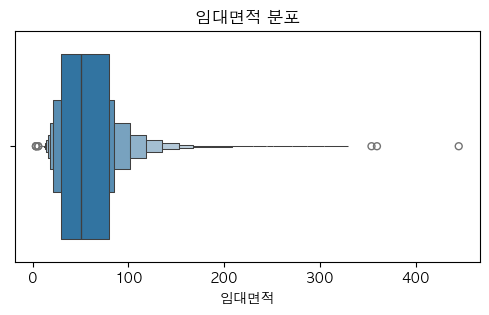

In [196]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

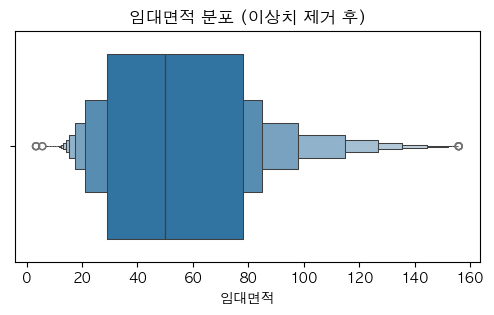

In [197]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


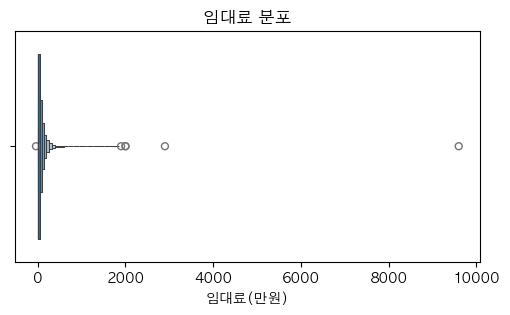

In [198]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

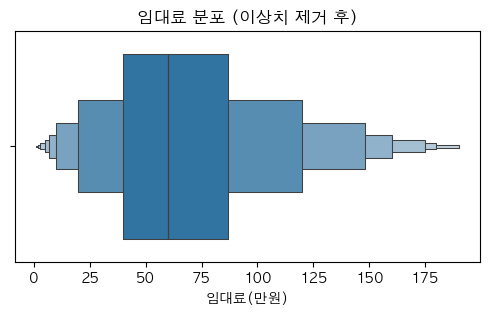

In [199]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

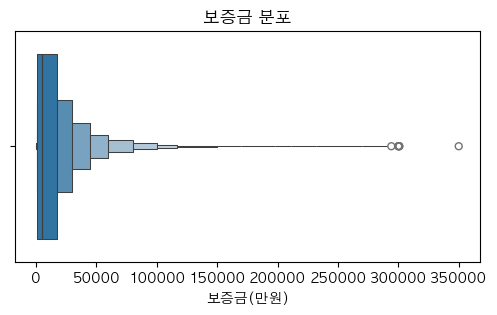

In [200]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

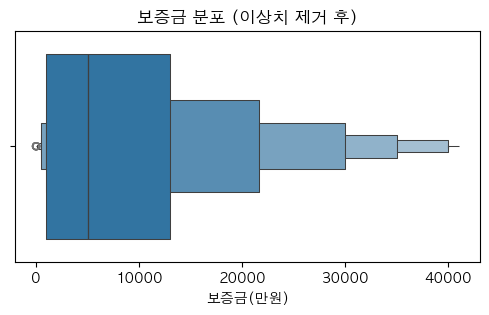

In [201]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

## Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [202]:
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
         임대면적  임대료(만원)  단위면적당_월세
509048  15.75       10  0.634921
509051  15.75       15  0.952381
509052  15.75       38  2.412698
509056  15.84        7  0.441919
509058  15.84       35  2.209596


### 건물 관련 컬럼

In [203]:
# 층을 범주화 해서 층_cat 컬럼 생성
df['층_cat'] = pd.cut(
    df['층'],
    bins=[-5, 0, 4, 10, 100],
    labels=['지하/반지하', '저층', '중층', '고층']
)

# 출력
df[['층', '층_cat']].head()

,층,층_cat
509048,4.0,저층
509051,5.0,중층
509052,4.0,저층
509056,4.0,저층
509058,3.0,저층


In [204]:
# 건물연령 컬럼 생성
# 낡은 건물 vs 신축은 월세가 크게 다르기 때문에 건물연령을 계산하여 새로운 컬럼으로 추가

df['건물연령'] = df['접수년도'] - df['건축년도']
df['건물연령'] = df['건물연령'].clip(lower=0)  # 혹시 이상한 값 방지

In [205]:
# 임대료 시즌성 반영을 위해 계약일에서 월/분기 정보 추출

df = df.reset_index(drop=True)

df['계약일'] = pd.to_datetime(
    df['계약일'].astype(str),   # 문자열로 바꾸고
    format='%Y%m%d',            # "YYYYMMDD" 형식이라고 알려주기
    errors='coerce'             # 이상한 값은 NaT로
)

df['계약월'] = df['계약일'].dt.month
df['계약분기'] = df['계약일'].dt.quarter

df[['계약일', '계약월', '계약분기']]

,계약일,계약월,계약분기
0,2021-08-05,8,3
1,2021-10-02,10,4
2,2021-10-27,10,4
3,2021-09-30,9,3
4,2021-12-13,12,4
...,...,...,...
453718,2024-12-16,12,4
453719,2024-12-16,12,4
453720,2024-12-16,12,4
453721,2025-03-08,3,1


In [206]:
# 계약기간
# 예: '24개월', '12개월' 이런 식이라고 가정
df['계약기간_월'] = (
    df['계약기간']
    .str.extract(r'(\d+)')
    .astype(float)
)

df[['계약기간', '계약기간_월']]

,계약기간,계약기간_월
0,21.08~23.08,21.0
1,21.10~22.10,21.0
2,21.10~22.10,21.0
3,21.10~23.10,21.0
4,21.12~23.12,21.0
...,...,...
453718,25.02~27.02,25.0
453719,25.03~27.03,25.0
453720,.~26.12,26.0
453721,24.02~26.02,24.0


### 대학가 컬럼 생성

In [208]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 37690 entries, 47 to 453719
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   접수년도      37690 non-null  int64         
 1   자치구명      37690 non-null  object        
 2   법정동명      37690 non-null  object        
 3   전월세구분     37690 non-null  object        
 4   임대면적      37690 non-null  float64       
 5   보증금(만원)   37690 non-null  int64         
 6   임대료(만원)   37690 non-null  int64         
 7   건물용도      37690 non-null  object        
 8   층         37690 non-null  float64       
 9   건축년도      37690 non-null  float64       
 10  계약일       37690 non-null  datetime64[ns]
 11  계약기간      37690 non-null  object        
 12  단위면적당_월세  37690 non-null  float64       
 13  층_cat     37690 non-null  category      
 14  건물연령      37690 non-null  float64       
 15  계약월       37690 non-null  in

In [209]:
df_analysis.columns

Index(['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도',
       '층', '건축년도', '계약일', '계약기간', '단위면적당_월세', '층_cat', '건물연령', '계약월', '계약분기',
       '계약기간_월', '대학가'],
      dtype='object')

In [218]:
# 최종 데이터프레임 확인
df_analysis.head()

,접수년도,자치구명,법정동명,전월세구분,임대면적,보증금(만원),임대료(만원),건물용도,층,건축년도,계약일,계약기간,단위면적당_월세,층_cat,건물연령,계약월,계약분기,계약기간_월,대학가
47,2021,관악구,신림동,월세,29.65,500,70,오피스텔,2.0,2013.0,2021-06-28,21.07~22.07,2.360877,저층,8.0,6,2,21.0,서울대
48,2021,관악구,신림동,월세,22.44,2000,35,오피스텔,4.0,2003.0,2021-07-21,21.08~22.08,1.559715,저층,18.0,7,3,21.0,서울대
49,2021,관악구,신림동,월세,19.92,500,40,오피스텔,4.0,2002.0,2021-04-19,21.04~22.04,2.008032,저층,19.0,4,2,21.0,서울대
51,2021,관악구,신림동,월세,19.89,500,55,오피스텔,4.0,2012.0,2021-05-30,21.06~22.06,2.765209,저층,9.0,5,2,21.0,서울대
52,2021,관악구,신림동,월세,16.47,3000,35,오피스텔,2.0,2004.0,2021-11-27,21.12~23.12,2.125076,저층,17.0,11,4,21.0,서울대


# EDA

In [219]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      19347
서울시립대     8321
서울교대      5900
홍익대       4122
Name: count, dtype: int64


In [220]:
# '단위면적당_월세'의 기술 통계량 확인
print(df_analysis['단위면적당_월세'].describe())

count    37690.000000
mean         2.226492
std          1.385550
min          0.020610
25%          1.124385
50%          2.093643
75%          3.134059
max         12.054507
Name: 단위면적당_월세, dtype: float64


### 단위면적당 월세 분포 확인

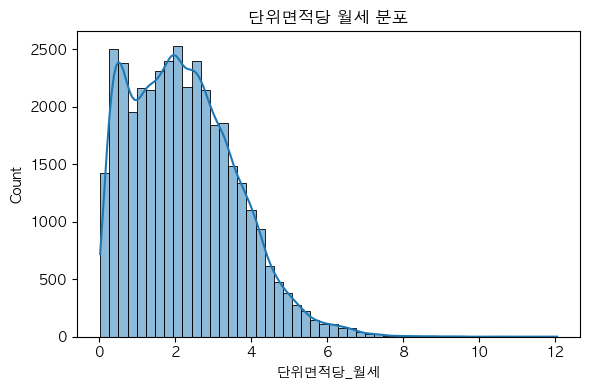

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_analysis['단위면적당_월세'], bins=50, kde=True)
plt.title('단위면적당 월세 분포')
plt.xlabel('단위면적당_월세')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Correlation Plot

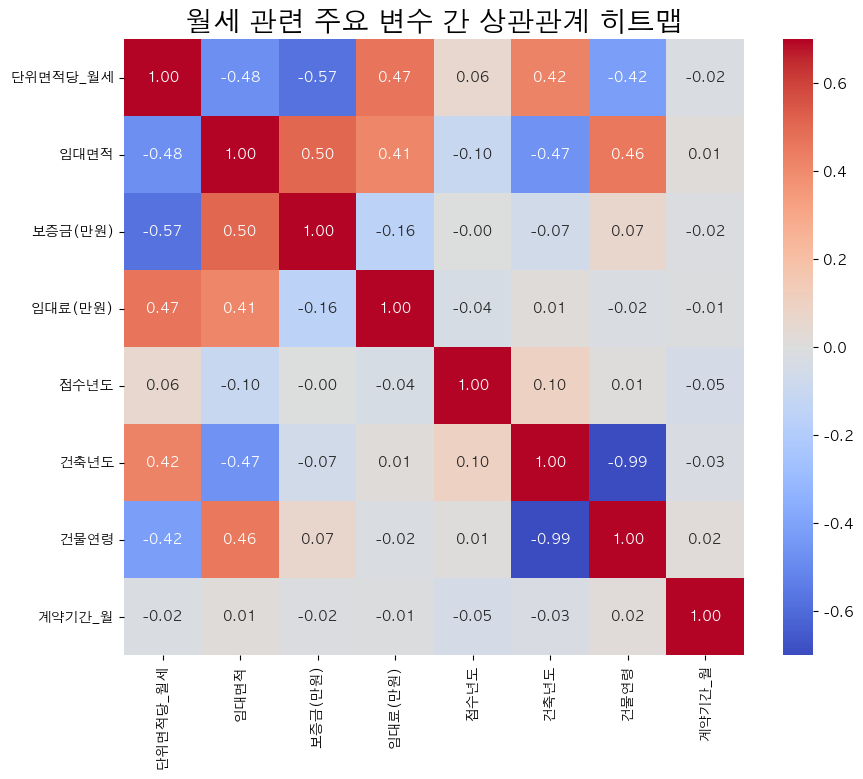

In [221]:
# 1. 수치형 변수 선택
numerical_cols = ['단위면적당_월세', '임대면적', '보증금(만원)', '임대료(만원)', '접수년도', '건축년도', '건물연령', '계약기간_월']
correlation_data = df_analysis[numerical_cols]

# 2. 상관 행렬 계산
correlation_matrix = correlation_data.corr()

# 3. 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.7, vmax=0.7)
plt.title('월세 관련 주요 변수 간 상관관계 히트맵', fontsize=20)
plt.show()

### 대학가별 단위면적당 월세 분포 Violin Plot

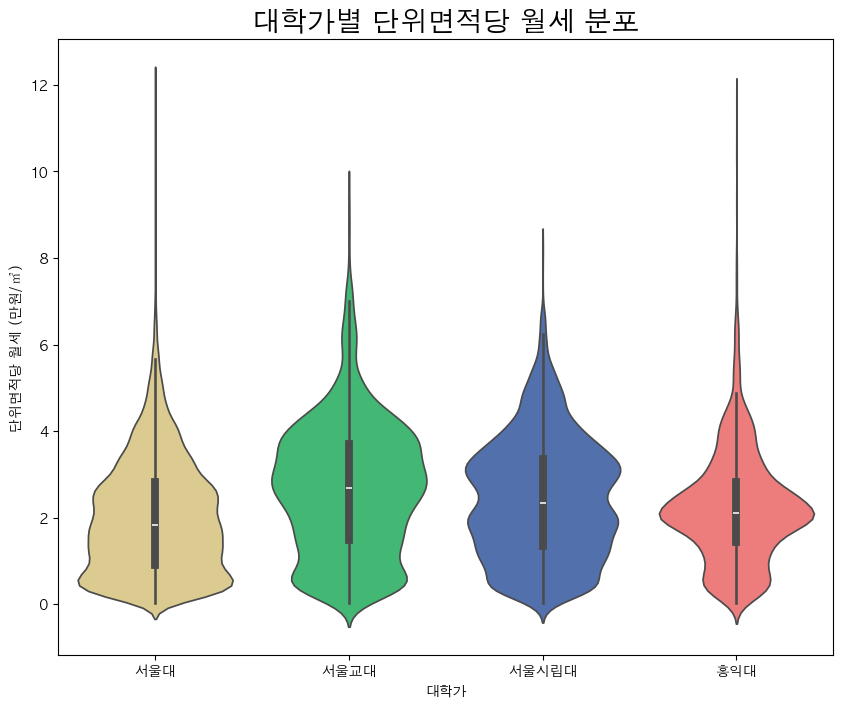

In [213]:
# plotting
plt.figure(figsize=(10, 8))
sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 단위면적당 월세 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 건물연령에 따른 분포 확인

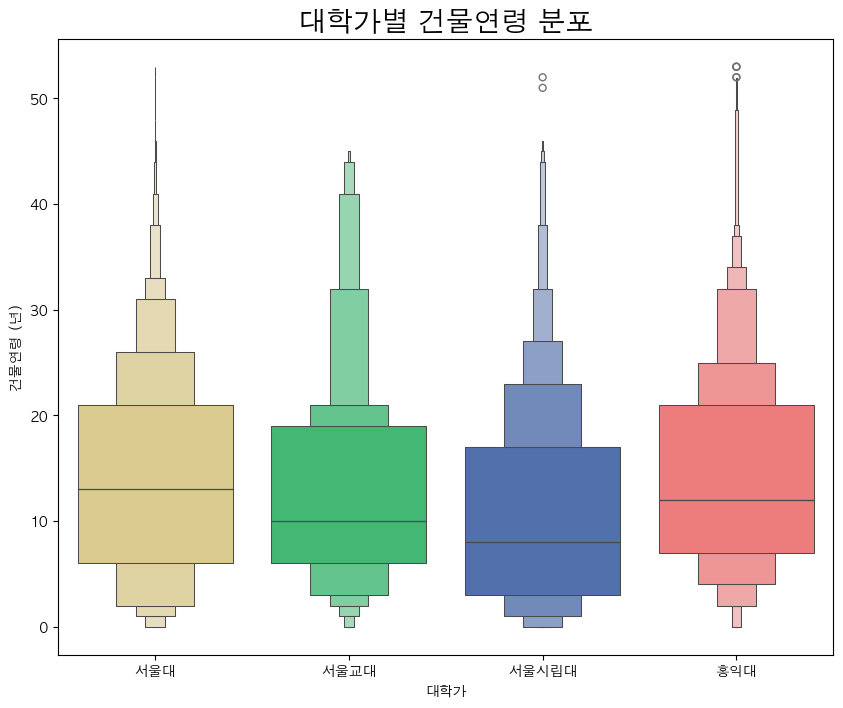

In [ ]:
# 건물연령에 따른 분포 확인
plt.figure(figsize=(10, 8))
sns.boxenplot(x='대학가', y='건물연령', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 건물연령 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('건물연령 (년)')
plt.show()

### 계약월/분기별 시즌성 분석

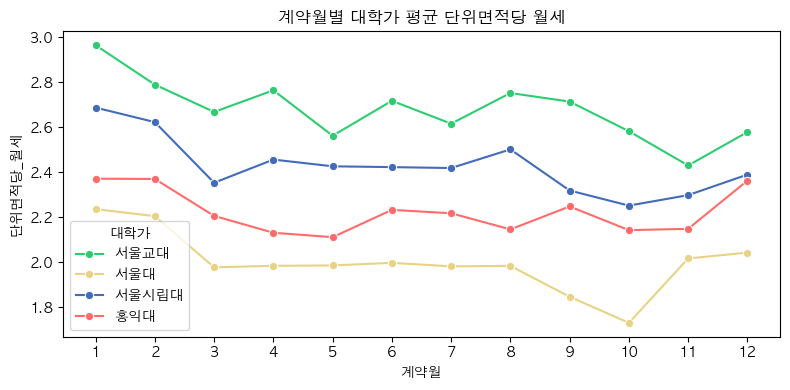

In [225]:
month_univ = (
    df_analysis
    .groupby(['계약월', '대학가'])['단위면적당_월세']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
sns.lineplot(data=month_univ, x='계약월', y='단위면적당_월세', hue='대학가', marker='o', palette=['#2ECC71', '#E8D284',  '#436BBA', '#FF6B6B'])
plt.title('계약월별 대학가 평균 단위면적당 월세')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

### 임대면적 vs 단위면적당 월세

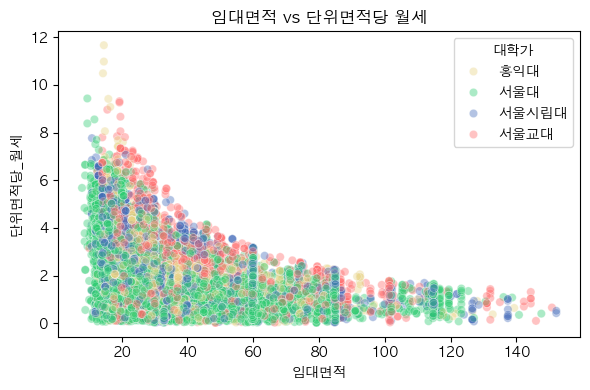

In [226]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_analysis.sample(20000, random_state=0),  # 너무 많으면 샘플링
                x='임대면적', y='단위면적당_월세', hue='대학가', alpha=0.4, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('임대면적 vs 단위면적당 월세')
plt.tight_layout()
plt.show()

### 건물연령 vs 단위면적당 월세

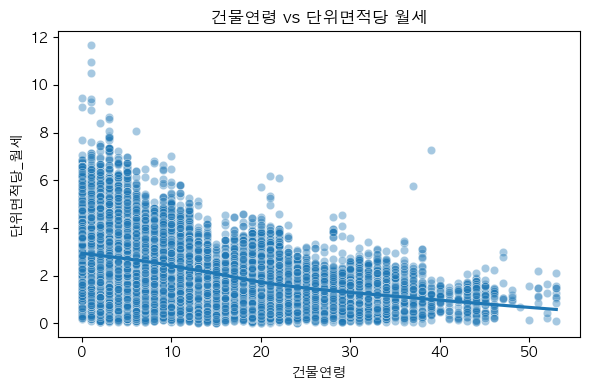

In [230]:
# “신축일수록 비싸다”는 직관이 실제 데이터에 맞는지 시각적으로 보여줌

plt.figure(figsize=(6,4))
sns.scatterplot(data=df_analysis.sample(20000, random_state=0),
                x='건물연령', y='단위면적당_월세', alpha=0.4)
sns.regplot(data=df_analysis, x='건물연령', y='단위면적당_월세',
            scatter=False, lowess=True)   # 추세선만
plt.title('건물연령 vs 단위면적당 월세')
plt.tight_layout()
plt.show()

### 보증금 vs 단위면적당 월세

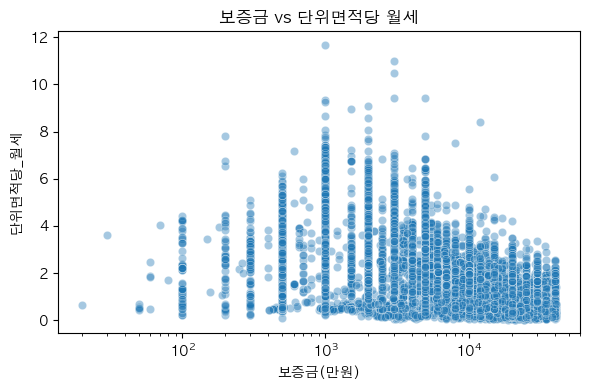

In [ ]:
# “보증금 많이 걸수록 월세가 낮아지는지” 관찰.
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_analysis.sample(20000, random_state=0),
                x='보증금(만원)', y='단위면적당_월세', alpha=0.4)
plt.xscale('log')  # 보증금 스케일 크면 로그축 추천
plt.title('보증금 vs 단위면적당 월세')
plt.tight_layout()
plt.show()

### 건물용도별 월세

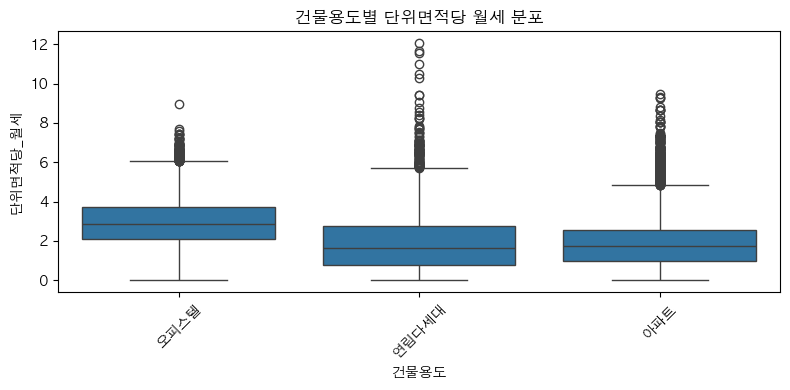

In [232]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_analysis, x='건물용도', y='단위면적당_월세')
plt.title('건물용도별 단위면적당 월세 분포')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

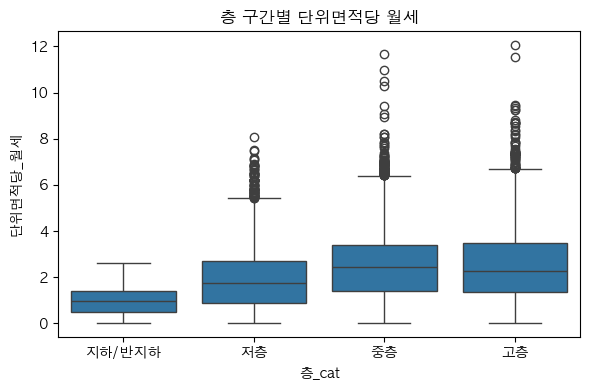

In [233]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_analysis, x='층_cat', y='단위면적당_월세')
plt.title('층 구간별 단위면적당 월세')
plt.tight_layout()
plt.show()

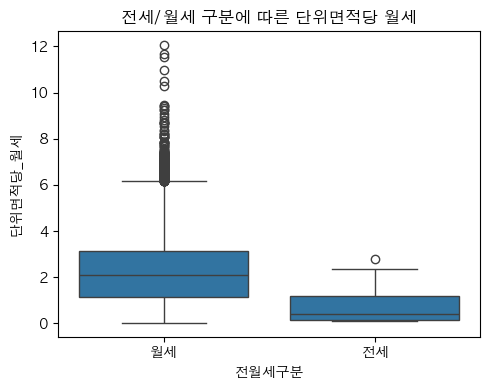

In [234]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df_analysis, x='전월세구분', y='단위면적당_월세')
plt.title('전세/월세 구분에 따른 단위면적당 월세')
plt.tight_layout()
plt.show()

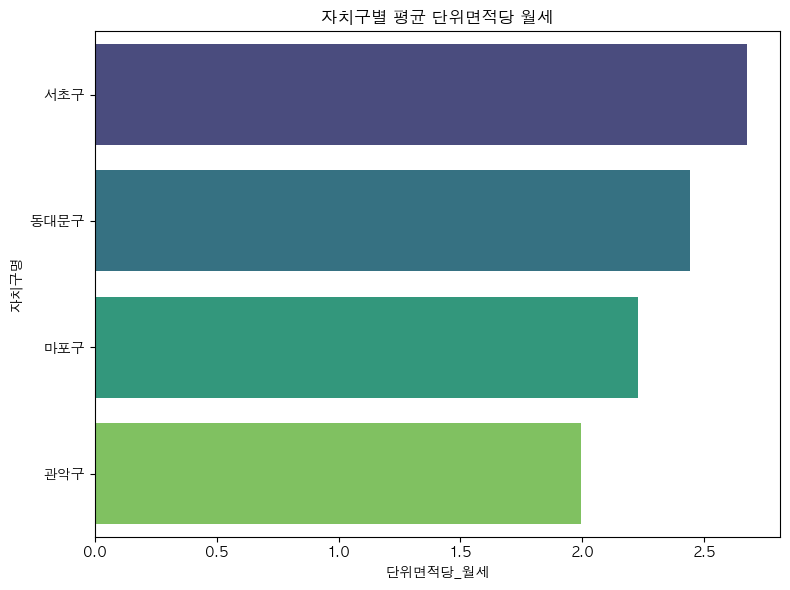

In [236]:
gu_mean = (
    df_analysis
    .groupby('자치구명')['단위면적당_월세']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,6))
sns.barplot(data=gu_mean, x='단위면적당_월세', y='자치구명', palette='viridis')
plt.title('자치구별 평균 단위면적당 월세')
plt.tight_layout()
plt.show()

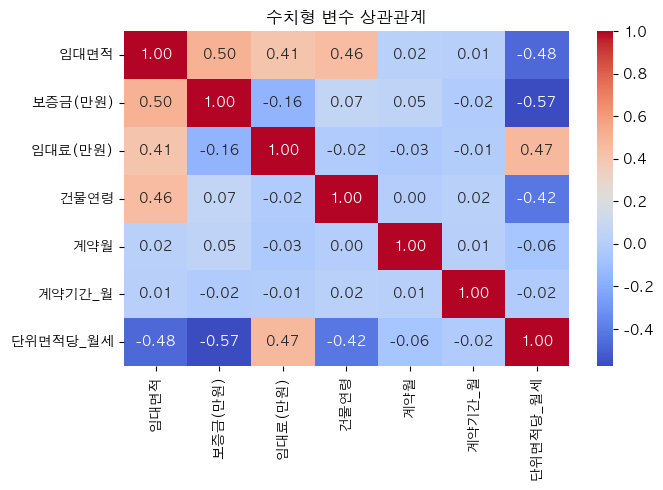

In [237]:
num_cols = ['임대면적', '보증금(만원)', '임대료(만원)',
            '건물연령', '계약월', '계약기간_월', '단위면적당_월세']

corr = df_analysis[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

### 평균비교

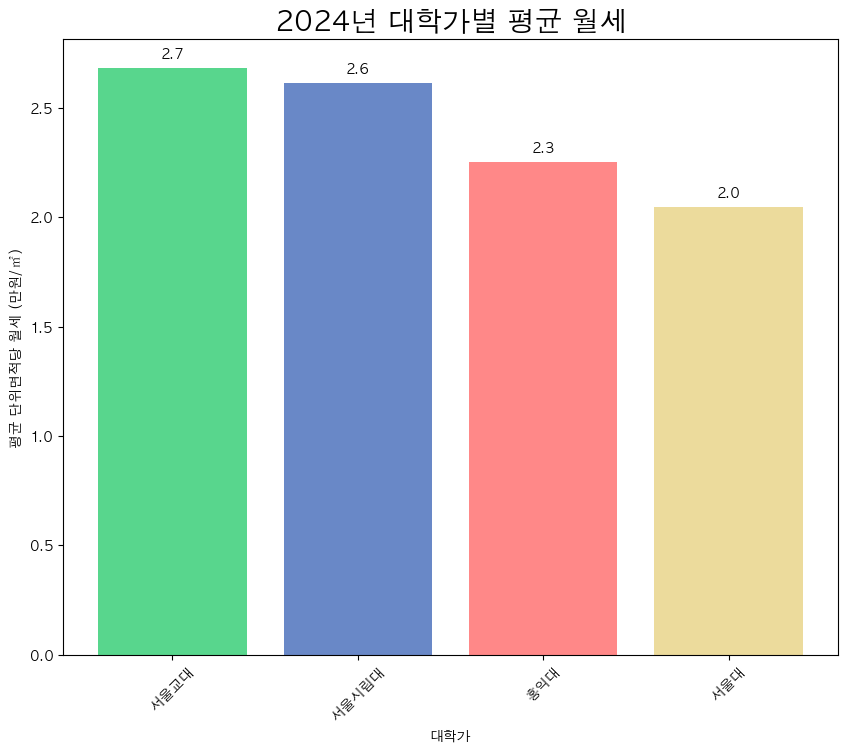

In [214]:
# 2024년 데이터 만 필터링
df_all_univ_2024 = df_analysis[df_analysis['접수년도'] == 2024]

# 평균 비교 막대그래프
plt.figure(figsize=(10, 8))
mean_by_univ = df_all_univ_2024.groupby('대학가')['단위면적당_월세'].mean().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(mean_by_univ.index, mean_by_univ.values, color=['#2ECC71', '#436BBA', '#FF6B6B', '#E8D284'], alpha=0.8)
plt.title('2024년 대학가별 평균 월세', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar, value in zip(bars, mean_by_univ.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.show()


## 신뢰도 분석

### Bootstrap

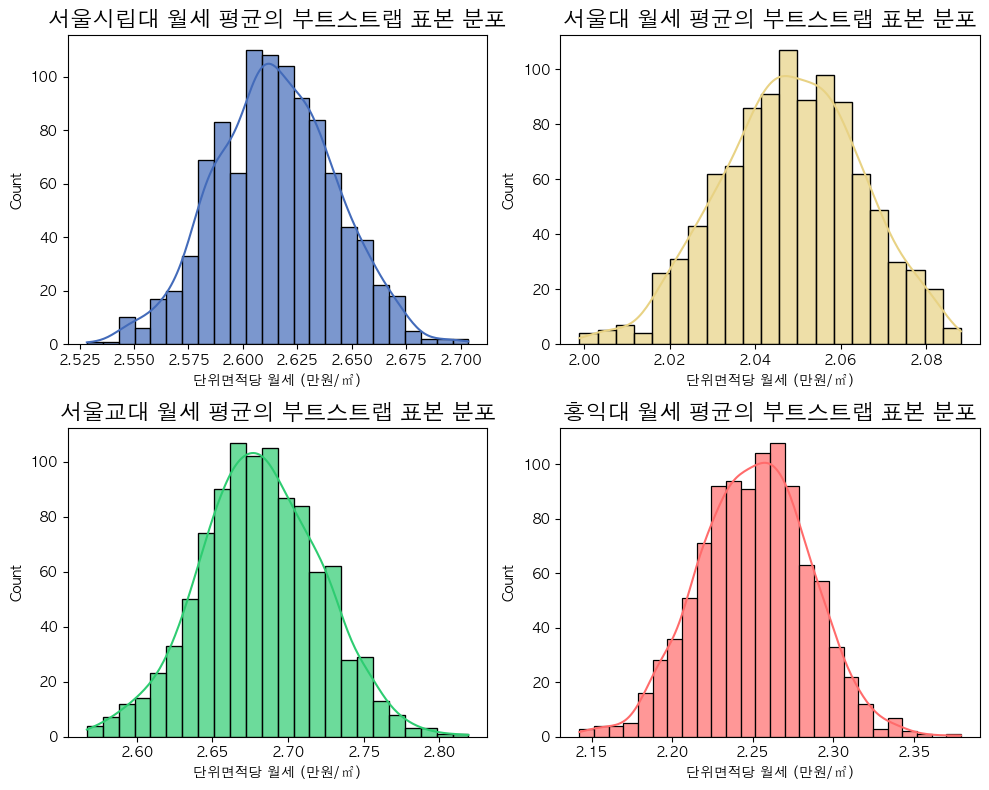

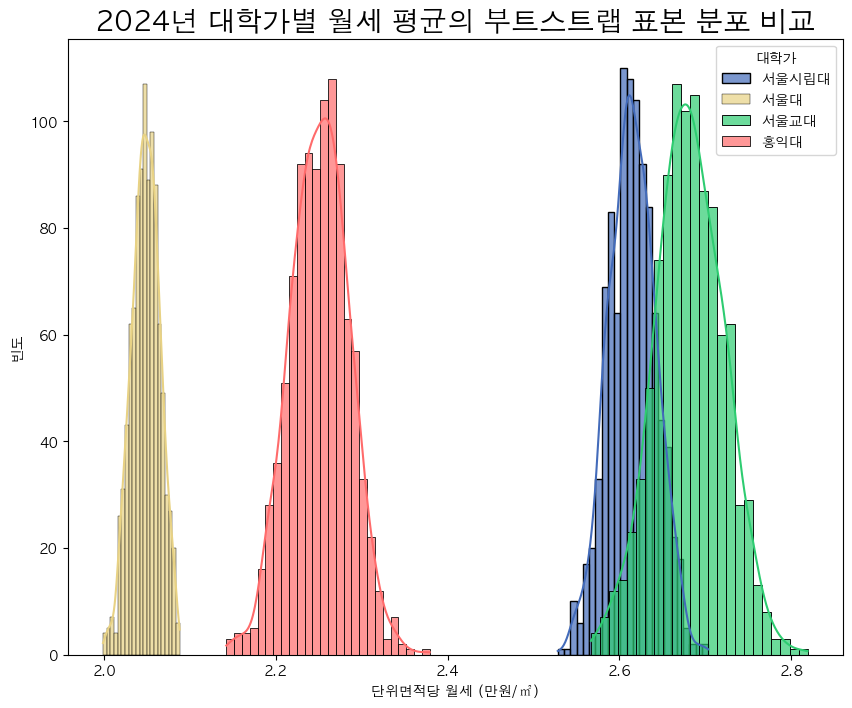

In [155]:
# 2024년 각 대학가별 데이터 분리
df_seoul_city_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울시립대']
df_seoul_nat_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울대']
df_seoul_edu_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울교대']
df_hongik_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '홍익대']

# 모든 대학가에 대해 부트스트랩 수행
universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_seoul_city_2024, df_seoul_nat_2024, 
            df_seoul_edu_2024, df_hongik_2024]
bootstrap_results = {}

for univ, data in zip(universities, datasets):
    bootstrap_means = []
    for _ in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    bootstrap_results[univ] = bootstrap_means

# 시각화
plt.figure(figsize=(10, 8))

colors=['#436BBA', '#E8D284', '#2ECC71', '#FF6B6B']

# 개별 대학가별 부트스트랩 분포
for i, (univ, color) in enumerate(zip(universities, colors)):
    plt.subplot(2, 2, i+1)
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, color=color)
    plt.title(f'{univ} 월세 평균의 부트스트랩 표본 분포', fontsize=16)
    plt.xlabel('단위면적당 월세 (만원/㎡)')

plt.tight_layout()
plt.show()

# 모든 대학가 부트스트랩 결과를 하나의 그래프로 비교
plt.figure(figsize=(10, 8))

for univ, color in zip(universities, colors):
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, label=univ, color=color)

plt.title('2024년 대학가별 월세 평균의 부트스트랩 표본 분포 비교', fontsize=20)
plt.xlabel('단위면적당 월세 (만원/㎡)')
plt.ylabel('빈도')
plt.legend(title='대학가')
plt.show()

### 각 대학별 95% 신뢰구간 계산

In [156]:
for univ in universities:
    bootstrap_means_univ = bootstrap_results[univ]
    
    # 95% 신뢰구간 계산
    lower_bound = np.percentile(bootstrap_means_univ, 2.5)
    upper_bound = np.percentile(bootstrap_means_univ, 97.5)
    
    # 표준오차 계산
    std_error = np.std(bootstrap_means_univ)
    
    # 평균 계산
    mean_val = np.mean(bootstrap_means_univ)
    
    print(f"=== {univ} ===")
    print(f"단위면적당 월세 평균: {mean_val:.2f} 만원")
    print(f"95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}] 만원")
    print(f"표준오차: {std_error:.2f} 만원")
    print()

=== 서울시립대 ===
단위면적당 월세 평균: 2.61 만원
95% 신뢰구간: [2.56, 2.67] 만원
표준오차: 0.03 만원

=== 서울대 ===
단위면적당 월세 평균: 2.05 만원
95% 신뢰구간: [2.02, 2.08] 만원
표준오차: 0.02 만원

=== 서울교대 ===
단위면적당 월세 평균: 2.68 만원
95% 신뢰구간: [2.60, 2.76] 만원
표준오차: 0.04 만원

=== 홍익대 ===
단위면적당 월세 평균: 2.25 만원
95% 신뢰구간: [2.19, 2.32] 만원
표준오차: 0.03 만원



### QQ plot

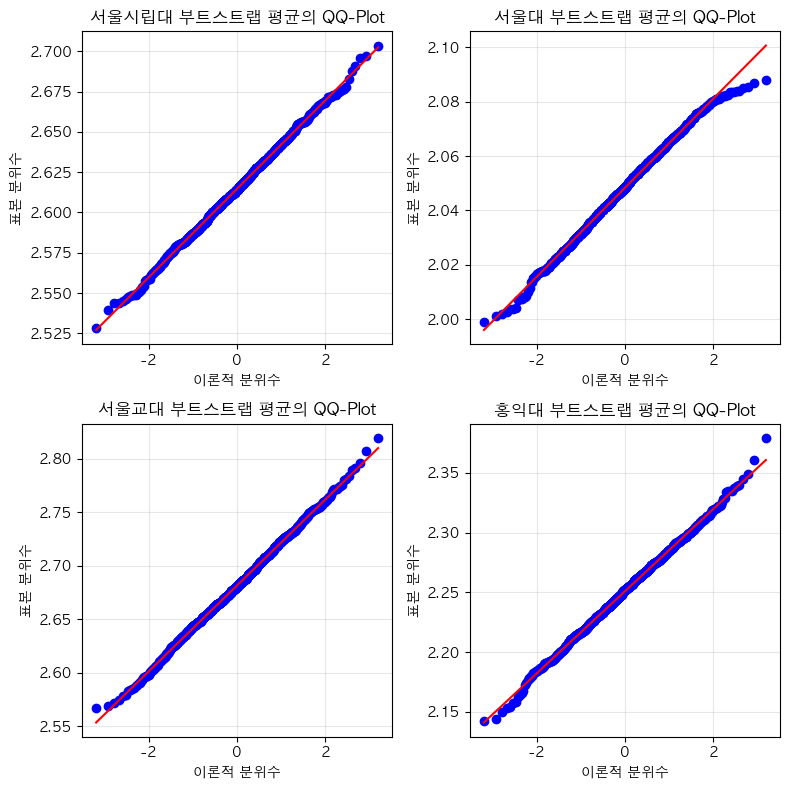

In [157]:
from scipy import stats

plt.figure(figsize=(8, 8))

# 각 대학가별 QQ-Plot
for i, univ in enumerate(universities):
    plt.subplot(2, 2, i+1)
    stats.probplot(bootstrap_results[univ], dist="norm", plot=plt)
    plt.title(f'{univ} 부트스트랩 평균의 QQ-Plot')
    plt.xlabel('이론적 분위수')
    plt.ylabel('표본 분위수')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 연도별 대학가 단위면적당 월세 변화 분석

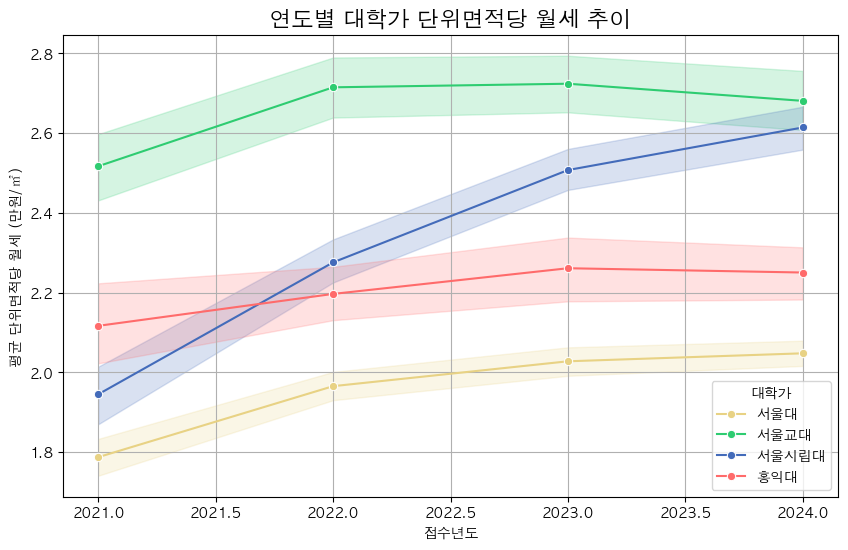

In [158]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'], marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

### 월세 증가율

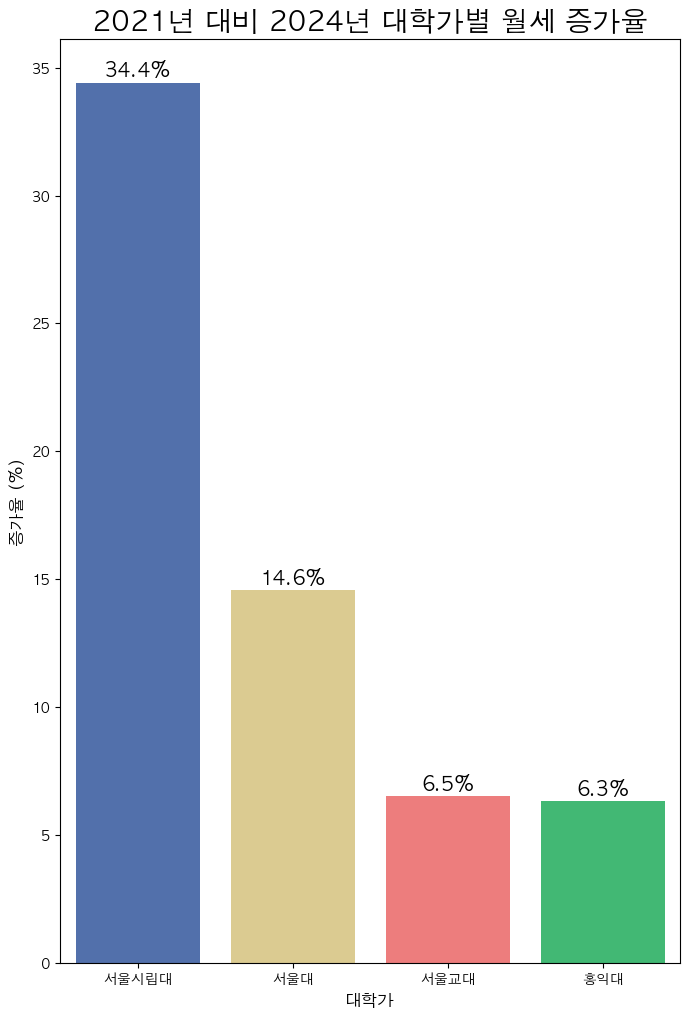

In [159]:
# 1. 증가율 계산
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# 2. 증가율을 내림차순으로 정렬
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 3. 막대그래프로 시각화
plt.figure(figsize=(8, 12))
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0)

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                
plt.show()

# Hypothesis test 

## 가설1 
: 2024년도 평균월세 차이는 과연 통계적으로 유의미한가? 

In [160]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_2024 = df_all_univ_2024.copy()

### 가설 1-A: 서울교대 vs. 서울대 (두 그룹 비교, t-test)

- 평균 월세가 가장 많이 차이나는 두 그룹을 비교

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울대}$ (두 대학가 간 평균 월세 차이가 없다.)

대립가설($H_1$): $\mu_{서울교대} > \mu_{서울대}$ (서울교대 인근 평균 월세가 더 비싸다.)

In [161]:
# --- [ 가설 1-A 검증: Independent Two-sample t-test ] ---
print("--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---")

# 1. 각 그룹의 샘플 데이터를 추출
rent_snu_edu = df_2024[df_2024['대학가'] == '서울교대']['단위면적당_월세']
rent_snu = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']

# 2. 등분산성 검정 (Levene's Test)
#    - p-value가 0.05보다 작으면 분산이 다르다고 가정 (equal_var=False).
levene_stat, levene_p = stats.levene(rent_snu_edu, rent_snu)
equal_var_flag = levene_p > 0.05 # True이면 등분산 가정, False이면 이분산 가정(Welch's T-test)

print(f"[등분산성 검정] p-value: {levene_p:.4f} (equal_var={equal_var_flag})")

# 3. Independent Two-sample t-test 수행
#    - alternative='greater': 서울교대(첫번째 인자)의 평균이 서울시립대(두번째 인자)보다 크다는 단측 검정
t_stat_1a, p_val_1a = stats.ttest_ind(
    rent_snu_edu, 
    rent_snu, 
    equal_var=equal_var_flag, 
    alternative='greater'
)

print(f"t-statistic: {t_stat_1a:.4f}")
print(f"p-value: {p_val_1a:.4f}")

# 4. 결과 해석
alpha = 0.05
if p_val_1a < alpha:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.")
else:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세가 서울시립대 인근보다 유의미하게 비싸다고 말할 수 없습니다.")

--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---
[등분산성 검정] p-value: 0.0000 (equal_var=False)
t-statistic: 1.3905
p-value: 0.0822
▶ 결론: p-value(0.0822)가 유의수준(0.05)보다 크므로 귀무가설을 기각할 수 없습니다.
   따라서, 2024년 기준 서울교대 인근의 평균 월세가 서울시립대 인근보다 유의미하게 비싸다고 말할 수 없습니다.


--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---


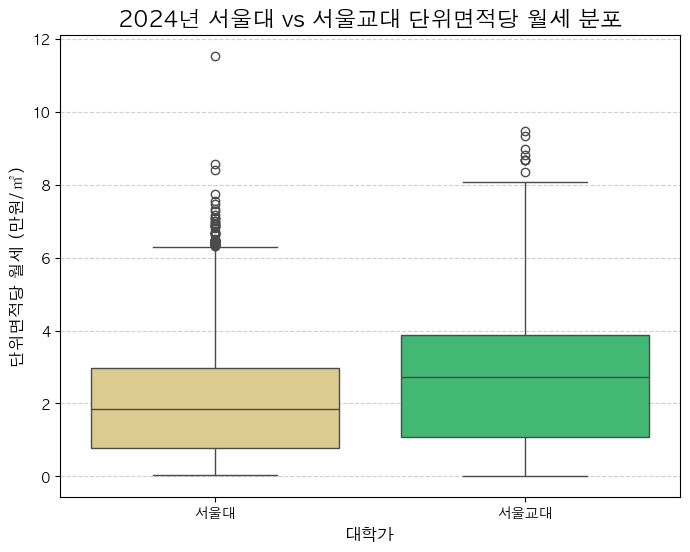

In [162]:
# --- [ 가설 1-A 시각화: Box Plot ] ---
print("--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---")

# 1. t-test에 사용된 두 그룹('서울대', '서울교대') 데이터만 필터링
df_1a_viz = df_2024[df_2024['대학가'].isin(['서울대', '서울교대'])]

# 2. Box Plot으로 두 그룹의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='대학가', 
    y='단위면적당_월세', 
    data=df_1a_viz, 
    palette=['#E8D284', '#2ECC71'], # EDA.ipynb의 [22]번 셀 색상 팔레트와 일치
    order=['서울대', '서울교대'] # 순서 지정
)

plt.title('2024년 서울대 vs 서울교대 단위면적당 월세 분포', fontsize=16)
plt.xlabel('대학가', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 1-B: 4개 대학가 전체 비교 (ANOVA)

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울시립대} = \mu_{서울대} = \mu_{홍익대}$ 
    (모든 대학가 간 평균 월세가 동일하다.)

대립가설($H_1$): 모든 대학가의 평균 월세가 동일한 것은 아니다. (적어도 하나는 다르다.)

In [163]:
# --- [ 가설 1-B 검증: ANOVA 및 Tukey's HSD 사후 검정 ] ---
print("\n--- 가설 1-B 검증 (4개 대학가 전체 비교) ---")

# 1. ANOVA 검증을 위해 나머지 대학가 데이터도 추출
rent_uos = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']
rent_hongik = df_2024[df_2024['대학가'] == '홍익대']['단위면적당_월세']

# 2. 일원배치 분산분석 (One-way ANOVA) 수행
f_stat_1b, p_val_1b = stats.f_oneway(rent_snu_edu, rent_snu, rent_uos, rent_hongik)

print(f"[ANOVA 검증] F-statistic: {f_stat_1b:.4f}")
print(f"p-value: {p_val_1b:.4f}")

# 3. ANOVA 결과 해석
if p_val_1b < alpha:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.")
    print("\n   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.")
    
    # 4. 사후 검정 (Tukey's HSD)
    #    - ANOVA가 유의미할 때만 실행하여 어떤 그룹끼리 차이가 나는지 확인
    tukey_result = pairwise_tukeyhsd(
        df_2024['단위면적당_월세'], 
        df_2024['대학가'], 
        alpha=0.05
    )
    
    print(tukey_result)
    
else:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 4개 대학가 간 평균 월세 차이가 통계적으로 유의미하다고 말할 수 없습니다.")


--- 가설 1-B 검증 (4개 대학가 전체 비교) ---
[ANOVA 검증] F-statistic: 27.5371
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.

   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  서울교대    서울대  -0.6333    0.0 -0.7288 -0.5377   True
  서울교대  서울시립대  -0.0668 0.4041  -0.177  0.0435  False
  서울교대    홍익대  -0.4306    0.0 -0.5582 -0.3031   True
   서울대  서울시립대   0.5665    0.0  0.4852  0.6478   True
   서울대    홍익대   0.2026    0.0   0.099  0.3062   True
 서울시립대    홍익대  -0.3639    0.0 -0.4812 -0.2466   True
----------------------------------------------------


--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---


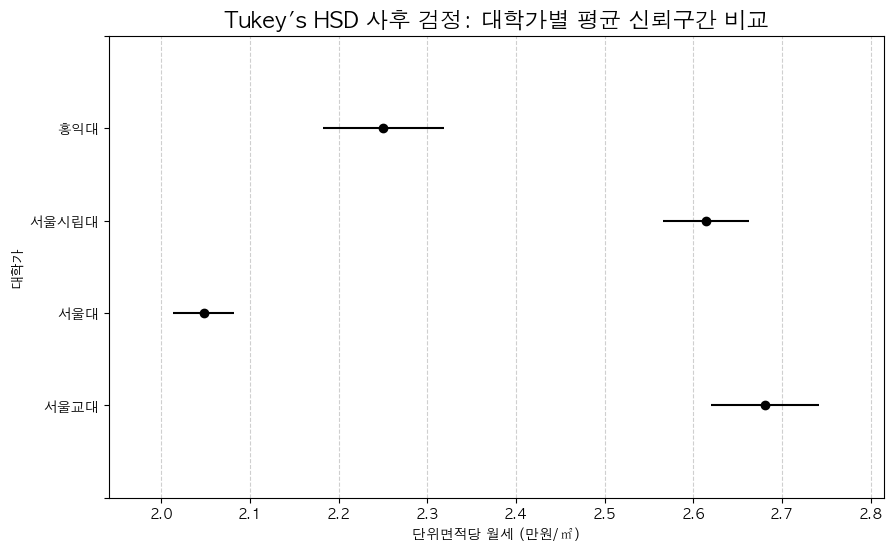

In [164]:
# --- [ 가설 1-B 시각화: Tukey's HSD Plot ] ---
print("--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---")

# 1. Tukey HSD 결과를 시각화합니다. (tukey_result 객체는 이전 셀에서 생성되어 있어야 함)
#    이 플롯은 각 그룹의 '평균'에 대한 95% 신뢰구간을 보여줍니다.
try:
    fig = tukey_result.plot_simultaneous(
        figsize=(10, 6), 
        xlabel='단위면적당 월세 (만원/㎡)',
        ylabel='대학가'
    )
    plt.title("Tukey's HSD 사후 검정: 대학가별 평균 신뢰구간 비교", fontsize=16)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.show()

except NameError:
    print("오류: 'tukey_result' 객체가 정의되지 않았습니다. [가설 1-B] 코드를 먼저 실행하세요.")

▶ 위 결과에 따라 각 그룹 간의 차이가 모두 통계적으로 유의미한 차이임을 알 수 있다.

## 가설 2
: 서울시립대 인근의 '가파른 월세 상승' 검증

In [165]:
import statsmodels.formula.api as smf

# 전체 기간 데이터 사용
df_full = df_analysis.copy()

### 가설 2-A: 2021년 전/후 시점 비교 (A/B 테스트)

서울시립대 인근의 평균 월세는 2021년을 기점으로 통계적으로 유의미하게 상승했는가?

귀무가설($H_0$): $\mu_{2021이후} = \mu_{2021이전}$ (2021년 전후의 평균 월세 차이가 없다.)
     
대립가설($H_1$): $\mu_{2021이후} > \mu_{2021이전}$ (2021년 이후 평균 월세가 더 높다.)

In [166]:
# 간단 주석 버전
print("--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---")

# 서울시립대 데이터만
df_uos_full = df_full[df_full['대학가'] == '서울시립대']

# 2020년까지 = 이전, 2021년부터 = 이후
rent_pre_2021 = df_uos_full[df_uos_full['접수년도'] <= 2020]['단위면적당_월세']
rent_post_2021 = df_uos_full[df_uos_full['접수년도'] >= 2021]['단위면적당_월세']

# 등분산성 검사
levene_stat_2a, levene_p_2a = stats.levene(rent_post_2021, rent_pre_2021)
equal_var_flag_2a = levene_p_2a > 0.05
print(f"[등분산성 검정] p-value: {levene_p_2a:.4f} (equal_var={equal_var_flag_2a})")

# 단측 t-test: 이후 > 이전
t_stat_2a, p_val_2a = stats.ttest_ind(
    rent_post_2021,
    rent_pre_2021,
    equal_var=equal_var_flag_2a,
    alternative='greater'
)

print(f"t-statistic: {t_stat_2a:.4f}")
print(f"p-value: {p_val_2a:.4f}")

# 해석 (alpha는 이전 셀에서 정의한 값 사용)
if p_val_2a < alpha:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) < {alpha} → 귀무가설 기각. 2021년 이후 상승이 유의미함.")
else:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) >= {alpha} → 귀무가설 기각 불가. 유의한 상승 아님.")


--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---
[등분산성 검정] p-value: nan (equal_var=False)
t-statistic: nan
p-value: nan
▶ 결론: p-value(nan) >= 0.05 → 귀무가설 기각 불가. 유의한 상승 아님.


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_26868/1783727536.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  levene_stat_2a, levene_p_2a = stats.levene(rent_post_2021, rent_pre_2021)
/opt/anaconda3/envs/SDS_env/lib/python3.11/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_26868/3663711558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')


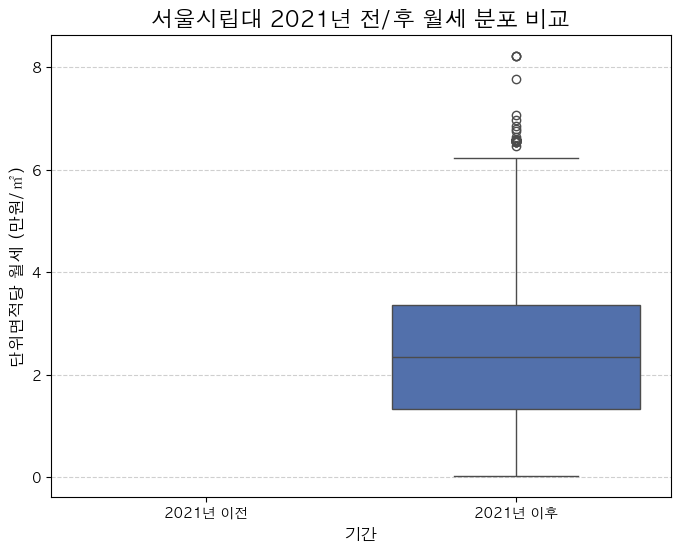

In [167]:
# --- [ 가설 2-A 시각화: Box Plot (2021년 전/후) ] ---
print("--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---")

# 1. 시각화를 위해 '기간' 컬럼을 생성합니다. (df_uos_full은 이전 셀에서 생성)
df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')

# 2. Box Plot으로 두 기간의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='기간', 
    y='단위면적당_월세', 
    data=df_uos_full,
    palette=['#AED6F1', '#436BBA'], # 이전/이후 색상 지정
    order=['2021년 이전', '2021년 이후'] # 순서 지정
)

plt.title('서울시립대 2021년 전/후 월세 분포 비교', fontsize=16)
plt.xlabel('기간', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 2-B: 타 대학가와의 '상승 추세' 비교 (회귀분석)

2021년 이후, 서울시립대 인근의 월세 상승폭은 서울대(대조군) 인근의 상승폭보다 통계적으로 유의미하게 더 컸는가?

귀무가설($H_0$): $\beta_3 = 0$ (서울시립대만의 추가적인 월세 상승 효과는 없다.)

대립가설($H_1$): $\beta_3 > 0$ (서울시립대만의 추가적인 월세 상승 효과가 유의미하게 존재한다.)

In [168]:
# --- [ 가설 2-B 검증: 회귀분석 (Difference-in-Differences) ] ---
print("\n--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---")

# 서울대와 서울시립대 데이터만 사용
df_did = df_full[df_full['대학가'].isin(['서울대', '서울시립대'])].copy()

# 더미 변수 생성: 2021년 이후, 서울시립대 여부
df_did['is_Post2021'] = (df_did['접수년도'] >= 2021).astype(int)
df_did['is_UOS'] = (df_did['대학가'] == '서울시립대').astype(int)

# DiD 회귀모형 (interaction 포함)
model = smf.ols(formula='단위면적당_월세 ~ is_Post2021 * is_UOS', data=df_did).fit()

# 결과 출력
print(model.summary())

# 상호작용항의 계수와 p-value 추출
interaction_term = 'is_Post2021:is_UOS'
interaction_coef = model.params[interaction_term]
interaction_pvalue = model.pvalues[interaction_term]

print(f"\n--- [ {interaction_term} ] 상호작용항 ---")
print(f"계수: {interaction_coef:.4f}")
print(f"p-value (양측): {interaction_pvalue:.4e}")

# 단측검정: 계수가 양수이고 (양측 p-value / 2) < alpha 이면 유의
p_val_one_sided = interaction_pvalue / 2

if (interaction_coef > 0) and (p_val_one_sided < alpha):
    print(f"▶ 결론: 계수 양수({interaction_coef:.4f})이고 단측 p-value({p_val_one_sided:.4e}) < {alpha} → 유의합니다.")
    print("   즉, 서울시립대의 2021년 이후 상승폭이 서울대보다 컸습니다.")
else:
    print("▶ 결론: 귀무가설을 기각할 수 없습니다. 서울시립대의 상승폭이 유의하게 더 크다고 보기 어렵습니다.")



--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---
                            OLS Regression Results                            
Dep. Variable:               단위면적당_월세   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     215.9
Date:                Tue, 25 Nov 2025   Prob (F-statistic):          2.00e-138
Time:                        20:58:21   Log-Likelihood:                -47202.
No. Observations:               27668   AIC:                         9.441e+04
Df Residuals:                   27664   BIC:                         9.444e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

▶ 회귀분석 결과, '서울시립대이면서 2021년 이후'를 나타내는 항의 계수가 +0.3057, 이 값의 p-valuerk 0.000 이다.

▶ 이는 2021년 이후 서울대, 홍익대, 서울교대 등 다른 대학가들이 공통적으로 겪은 월세 상승분(시간 효과, 0.4414)을 모두 제외하고도, 서울시립대 인근만 추가적으로 0.34 (만원/㎡)만큼 더 폭등했음을 의미

## 추가 분석

혜성, 신웅이 여기서부터 채우면 됨.

# Machine Learning

In [238]:
df_analysis.columns

Index(['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도',
       '층', '건축년도', '계약일', '계약기간', '단위면적당_월세', '층_cat', '건물연령', '계약월', '계약분기',
       '계약기간_월', '대학가'],
      dtype='object')

Training samples: 22567, Test samples: 15123
Fitting 4 folds for each of 30 candidates, totalling 120 fits
Best params: {'subsample': 0.6, 'n_estimators': 1200, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.05}
Test RMSE: 0.696
Test R²  : 0.792


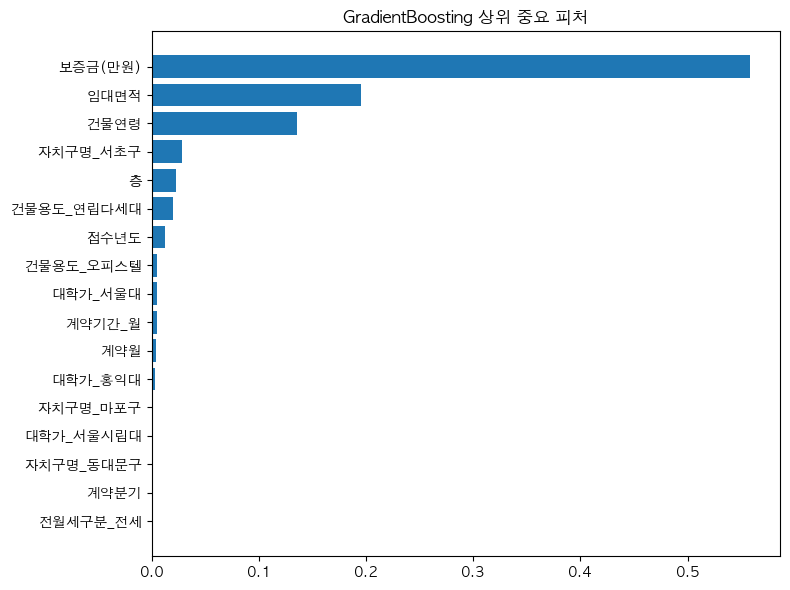

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================
# 1. 분석 대상 데이터 준비
# =========================

target = '단위면적당_월세'

# (1) 수치형 피처 + 범주형 피처 분리
num_features = [
    '접수년도',
    '임대면적',
    '보증금(만원)',
    '건물연령',
    '계약월',
    '계약분기',
    '계약기간_월',
    '층',             # 원하면 빼고 층_cat만 써도 됨
]

cat_features = [
    '대학가',
    '건물용도',
    '전월세구분',
    '자치구명',
    # '층_cat',      # 층_cat까지 쓰고 싶으면 주석 해제
]

features = num_features + cat_features

data_model = df_analysis[features + [target]].copy()

# 결측치 제거 (필요하면 다른 방식으로 처리해도 됨)
data_model = data_model.dropna(subset=[target])

# =========================
# 2. 범주형 변수 One-Hot Encoding
# =========================
data_model = pd.get_dummies(
    data_model,
    columns=cat_features,
    drop_first=True
)

# =========================
# 3. Train/Test Split (연도 기준)
# =========================
train_data = data_model[data_model['접수년도'] < 2024]
test_data  = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test  = test_data.drop(columns=[target])
y_test  = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# =========================
# 4. 타깃 로그 변환 (분포가 한쪽으로 치우쳐 있을 때 유리)
# =========================
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# =========================
# 5. TimeSeriesSplit + RandomizedSearch 로 GB 튜닝
# =========================
tscv = TimeSeriesSplit(n_splits=4)

param_dist = {
    "n_estimators": [200, 400, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [1, 5, 10, 20],
}

base_model = GradientBoostingRegressor(random_state=42)

"""
What is GradientBoostingRegressor?
    - decision tree 기반의 앙상블 학습 기법.
    - 여러 개의 약한 학습기(주로 결정 트리)를 순차적으로 학습시켜 강력한 예측 모델을 만듦.
    - 각 트리는 이전 트리의 오차를 보완하는 방식으로 학습됨.

why GradientBoostingRegressor?
    0. 시계열 데이터에 강함: 시계열 특성을 반영한 학습 가능.
    1. 강력한 예측 성능: 여러 약한 학습기를 결합하여 복잡한 패턴을 학습.
    2. 과적합 방지: 학습률과 트리 깊이 조절로 과적합 위험 감소.
    3. 다양한 손실 함수 지원: 회귀, 분류 등 다양한 문제에 적용 가능.
    4. 변수 중요도 제공: 예측에 기여하는 변수 파악 가능.
"""

## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이


search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train_log)
best_model = search.best_estimator_
print("Best params:", search.best_params_)

# =========================
# 6. 최종 2024년 테스트 성능
# =========================
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)   # 로그 되돌리기

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²  : {r2:.3f}")

# =========================
# 7. 피처 중요도도 한 번 보기 (옵션)
# =========================
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

n_features = len(importances)          # 실제 피처 개수
top_n = min(20, n_features)           # 최대 20개까지만 보기

plt.figure(figsize=(8,6))
plt.barh(range(top_n), importances[indices][:top_n])
plt.yticks(range(top_n), feature_names[indices][:top_n])
plt.gca().invert_yaxis()
plt.title("GradientBoosting 상위 중요 피처")
plt.tight_layout()
plt.show()

## 시각화

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.2, font="Apple SD Gothic Neo")  # 필요하면 폰트 설정 추가

# 예측값 / 잔차 / 오차율 정리
res_df = pd.DataFrame({
    "실제값": y_test,
    "예측값": y_pred,
})
res_df["오차"] = res_df["실제값"] - res_df["예측값"]          # (실제 - 예측)
res_df["오차율(%)"] = res_df["오차"] / res_df["실제값"] * 100

# 같은 인덱스를 이용해서 대학가 정보 붙이기
res_df["대학가"] = df_analysis.loc[res_df.index, "대학가"]

# 대학가별 색깔 팔레트
univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

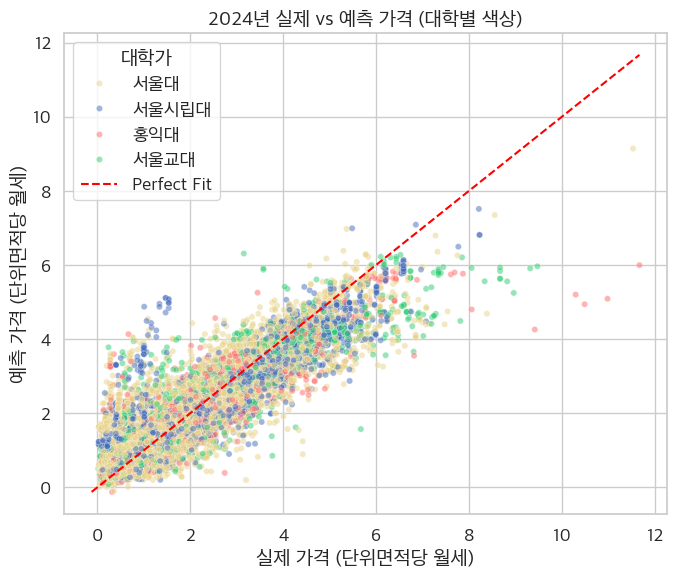

In [252]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=res_df,
    x="실제값",
    y="예측값",
    hue="대학가",
    palette=univ_palette,
    alpha=0.5,
    s=20,
)

# y = x 기준선 (완벽한 예측)
min_val = min(res_df["실제값"].min(), res_df["예측값"].min())
max_val = max(res_df["실제값"].max(), res_df["예측값"].max())
plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", color="red", label="Perfect Fit")

plt.xlabel("실제 가격 (단위면적당 월세)")
plt.ylabel("예측 가격 (단위면적당 월세)")
plt.title("2024년 실제 vs 예측 가격 (대학별 색상)")
plt.legend(title="대학가", loc="upper left")
plt.tight_layout()
plt.show()

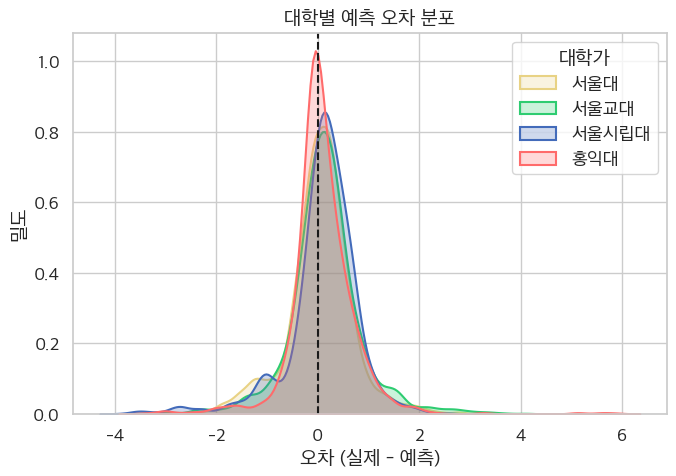

In [255]:
plt.figure(figsize=(7, 5))

for univ in univ_palette.keys():
    sns.kdeplot(
        data=res_df[res_df["대학가"] == univ],
        x="오차",
        fill=True,
        alpha=0.25,
        linewidth=1.5,
        color=univ_palette[univ],
        label=univ,
    )

plt.axvline(0, color="k", linestyle="--")  # 오차 0 기준선

plt.xlabel("오차 (실제 - 예측)")
plt.ylabel("밀도")
plt.title("대학별 예측 오차 분포")
plt.legend(title="대학가")
plt.tight_layout()
plt.show()

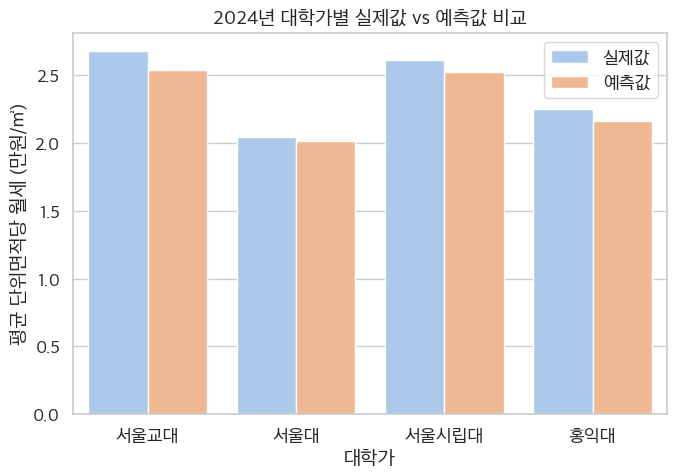

In [270]:
# 대학가별 평균 실제값 / 예측값
mean_df = (
    res_df.groupby("대학가")[["실제값", "예측값"]]
    .mean()
    .reset_index()
)

mean_long = mean_df.melt(
    id_vars="대학가",
    value_vars=["실제값", "예측값"],
    var_name="종류",
    value_name="평균단위면적당월세",
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=mean_long,
    x="대학가",
    y="평균단위면적당월세",
    hue="종류",
    palette="pastel",
)

plt.xlabel("대학가")
plt.ylabel("평균 단위면적당 월세 (만원/㎡)")
plt.title("2024년 대학가별 실제값 vs 예측값 비교")
plt.legend(title="")
plt.tight_layout()
plt.show()

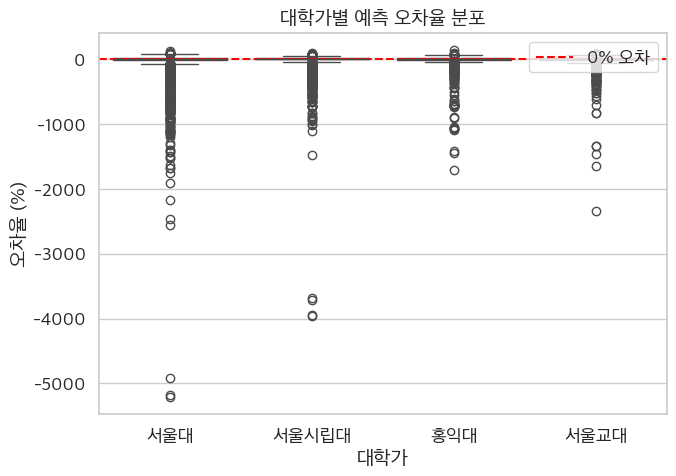

In [271]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=res_df,
    x="대학가",
    y="오차율(%)",
    palette=[univ_palette[u] for u in univ_palette.keys()],
)

plt.axhline(0, color="red", linestyle="--", label="0% 오차")

plt.xlabel("대학가")
plt.ylabel("오차율 (%)")
plt.title("대학가별 예측 오차율 분포")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

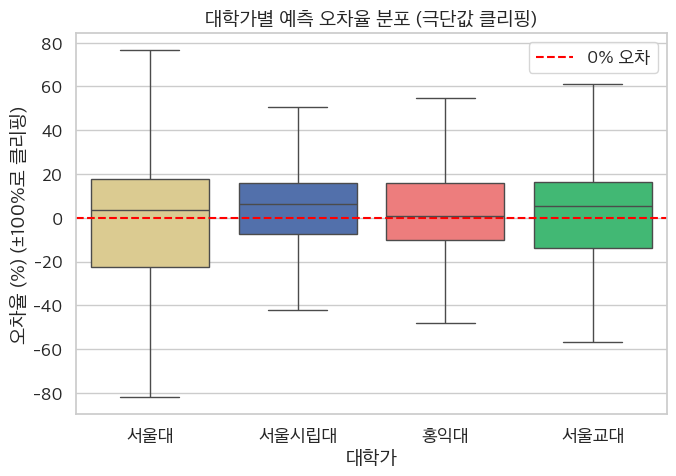

In [273]:
# 1. 오차율 클리핑 (예: -100% ~ 100% 사이만 보기)
res_df["오차율_clipped"] = res_df["오차율(%)"].clip(lower=-100, upper=100)

plt.figure(figsize=(7,5))
sns.boxplot(
    data=res_df,
    x="대학가",
    y="오차율_clipped",
    palette=univ_palette,  # 색 팔레트 쓰고 싶으면 그대로 넣기
    showfliers=False,   # 박스 밖 점은 숨기기
)
plt.axhline(0, color="red", linestyle="--", label="0% 오차")

plt.xlabel("대학가")
plt.ylabel("오차율 (%) (±100%로 클리핑)")
plt.title("대학가별 예측 오차율 분포 (극단값 클리핑)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 예측값에 따른 잔차 패턴 (모델이 어디에서 틀리는지)

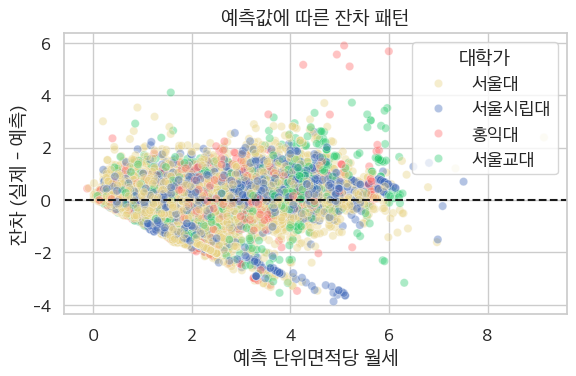

In [264]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=res_df, x="예측값", y="오차", hue="대학가", alpha=0.4, palette=univ_palette)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("예측 단위면적당 월세")
plt.ylabel("잔차 (실제 - 예측)")
plt.title("예측값에 따른 잔차 패턴")
plt.tight_layout()
plt.show()

### 핵심 피처별 잔차 패턴

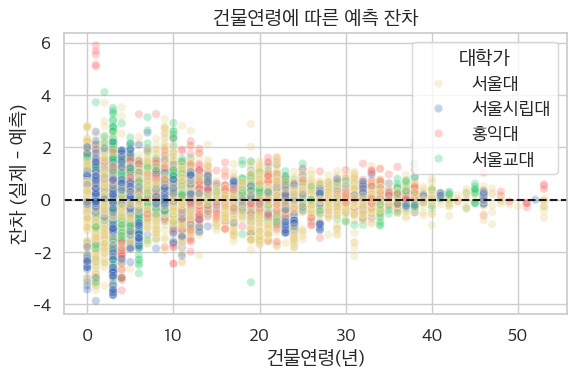

In [266]:
# 건물연령 vs 잔차
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=res_df,
    x=df_analysis.loc[res_df.index, "건물연령"],
    y="오차",
    alpha=0.3,
    hue="대학가",
    palette=univ_palette,
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("건물연령(년)")
plt.ylabel("잔차 (실제 - 예측)")
plt.title("건물연령에 따른 예측 잔차")
plt.tight_layout()
plt.show()

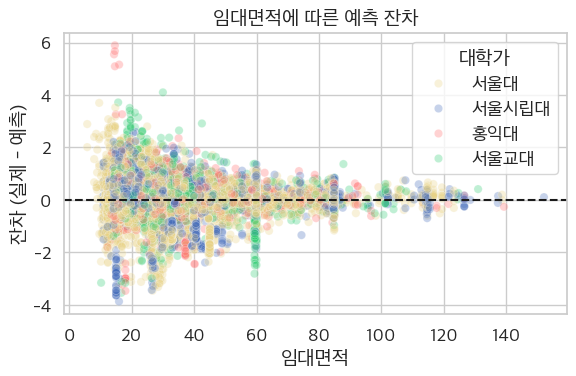

In [267]:
# 임대면적 vs 잔차
feature = "임대면적"  # 혹은 '보증금(만원)'
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=res_df,
    x=df_analysis.loc[res_df.index, feature],
    y="오차",
    alpha=0.3,
    hue=df_analysis.loc[res_df.index, "대학가"],
    palette=univ_palette,
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel(feature)
plt.ylabel("잔차 (실제 - 예측)")
plt.title(f"{feature}에 따른 예측 잔차")
plt.tight_layout()
plt.show()

### 예측값 구간별 Calibration 분석

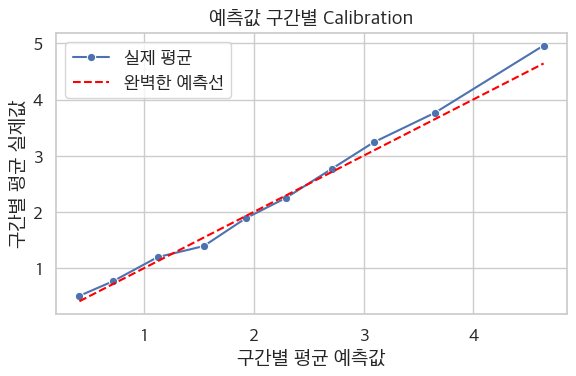

In [268]:
# 예측값 구간별 Calibration 분석
res_df_cal = res_df.copy()
res_df_cal["pred_bin"] = pd.qcut(res_df_cal["예측값"], q=10, duplicates="drop")  # 10분위

cal = (
    res_df_cal
    .groupby("pred_bin")[["실제값","예측값"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.lineplot(data=cal, x="예측값", y="실제값", marker="o", label="실제 평균")
plt.plot(cal["예측값"], cal["예측값"], "--", color="red", label="완벽한 예측선")
plt.xlabel("구간별 평균 예측값")
plt.ylabel("구간별 평균 실제값")
plt.title("예측값 구간별 Calibration")
plt.legend()
plt.tight_layout()
plt.show()


--- 2025년 대학가별 단위면적당 월세 예측 결과 ---
     대학가  2025_예측_단위면적당_월세
0    서울대          0.969619
1  서울시립대          1.482437
2   서울교대          1.304232
3    홍익대          1.540834


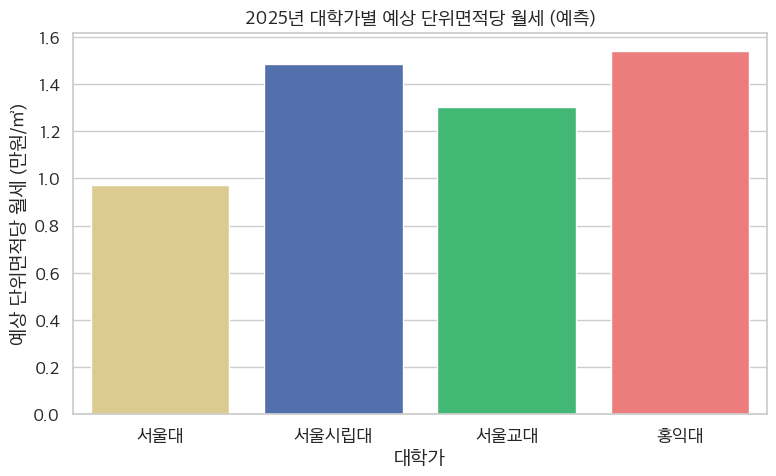

In [274]:
# =====================================================
# 7. 2025년 대학가별 단위면적당 월세 예측 (대표 샘플 기반)
# =====================================================

universities = ['서울대', '서울시립대', '서울교대', '홍익대']
future_predictions = []

univ_palette = {
    '서울대': '#E8D284',
    '서울시립대': '#436BBA',
    '서울교대': '#2ECC71',
    '홍익대': '#FF6B6B'
}

for univ in universities:
    # 1) 해당 대학가 데이터만 추출
    sub = df_analysis[df_analysis['대학가'] == univ]

    # 2) 대표적인 수치형 피처 값(평균) 계산
    univ_mean_area   = sub['임대면적'].mean()
    univ_mean_deposit = sub['보증금(만원)'].mean()
    univ_mean_age    = sub['건물연령'].mean()
    univ_mean_term   = sub['계약기간_월'].mean()
    univ_mean_floor  = sub['층'].mean()

    # 3) 대표적인 범주형 피처 값(최빈값) 계산
    mode_usage = sub['건물용도'].mode().iloc[0]     # 건물용도
    mode_lease = sub['전월세구분'].mode().iloc[0]   # 전월세구분
    mode_gu    = sub['자치구명'].mode().iloc[0]     # 자치구

    # 4) X_train과 같은 컬럼 구조를 가진 입력 한 행 생성
    input_row = pd.DataFrame(0, index=[0], columns=X_train.columns)

    # ---- 수치형 피처 채우기 ----
    input_row.loc[0, '접수년도']    = 2025
    input_row.loc[0, '임대면적']    = univ_mean_area
    input_row.loc[0, '보증금(만원)'] = univ_mean_deposit
    input_row.loc[0, '건물연령']    = univ_mean_age
    input_row.loc[0, '계약월']      = 3         # 예: 3월 계약이라고 가정 (원하면 바꿔도 됨)
    input_row.loc[0, '계약분기']    = 1         # 1분기
    input_row.loc[0, '계약기간_월'] = univ_mean_term
    input_row.loc[0, '층']          = univ_mean_floor

    # ---- 범주형 더미 컬럼 세팅 (있을 때만 1로) ----
    # 대학가
    col = f'대학가_{univ}'
    if col in input_row.columns:
        input_row.loc[0, col] = 1

    # 건물용도
    col = f'건물용도_{mode_usage}'
    if col in input_row.columns:
        input_row.loc[0, col] = 1

    # 전월세구분
    col = f'전월세구분_{mode_lease}'
    if col in input_row.columns:
        input_row.loc[0, col] = 1

    # 자치구명
    col = f'자치구명_{mode_gu}'
    if col in input_row.columns:
        input_row.loc[0, col] = 1

    # 5) 예측 수행 (로그타깃 → 원래 스케일 복원)
    pred_log = best_model.predict(input_row)[0]
    pred     = np.expm1(pred_log)

    future_predictions.append({
        '대학가': univ,
        '2025_예측_단위면적당_월세': pred
    })

# 6) 결과 정리
df_future = pd.DataFrame(future_predictions)
print("\n--- 2025년 대학가별 단위면적당 월세 예측 결과 ---")
print(df_future)

# 7) 시각화
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_future,
    x='대학가',
    y='2025_예측_단위면적당_월세',
    palette=[univ_palette[u] for u in df_future['대학가']]
)
plt.title('2025년 대학가별 예상 단위면적당 월세 (예측)', fontsize=14)
plt.ylabel('예상 단위면적당 월세 (만원/㎡)')
plt.xlabel('대학가')
plt.tight_layout()
plt.show()

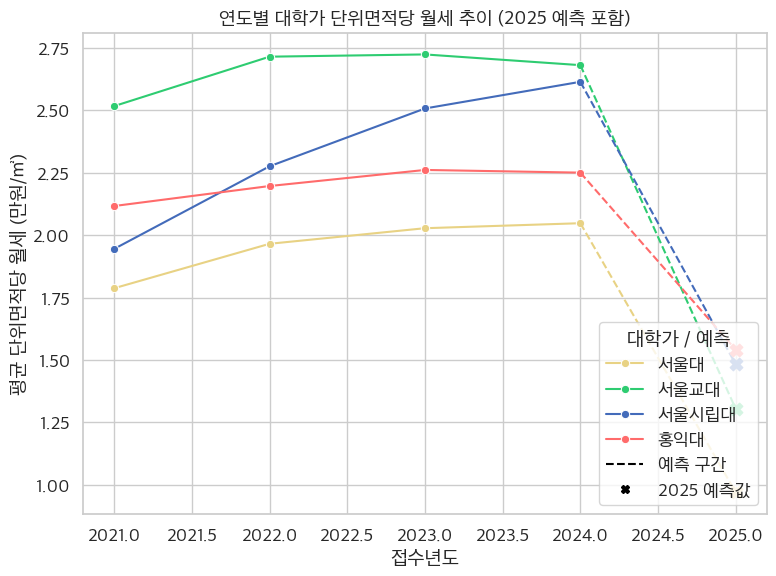

In [275]:
# ---------- 1. 2021~2024 실제 평균값 계산 ----------
mask = df_analysis['접수년도'].between(2021, 2024)

year_univ = (
    df_analysis[mask]
    .groupby(['접수년도', '대학가'])['단위면적당_월세']
    .mean()
    .reset_index()
)

# 대학가 순서 & 색상 (원래 쓰던 팔레트 그대로)
univ_order = ['서울대', '서울교대', '서울시립대', '홍익대']
univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

plt.figure(figsize=(8, 6))

# ---------- 2. 2021~2024 실제 추이 선 그래프 ----------
sns.lineplot(
    data=year_univ,
    x='접수년도',
    y='단위면적당_월세',
    hue='대학가',
    hue_order=univ_order,
    palette=univ_palette,
    marker='o'
)

# ---------- 3. 2025 예측값 이어 붙이기 ----------
for univ in univ_order:
    # 해당 대학가의 2024년 실제 평균
    last_actual = year_univ[
        (year_univ['대학가'] == univ) &
        (year_univ['접수년도'] == 2024)
    ]['단위면적당_월세'].values[0]

    # 해당 대학가의 2025년 예측값
    if univ not in df_future['대학가'].values:
        continue
    pred_value = df_future.loc[
        df_future['대학가'] == univ,
        '2025_예측_단위면적당_월세'
    ].values[0]

    # 2024 → 2025 구간 점선으로 연결
    plt.plot(
        [2024, 2025],
        [last_actual, pred_value],
        color=univ_palette[univ],
        linestyle='--'
    )

    # 2025 예측값을 X 마커로 표시
    plt.scatter(
        2025,
        pred_value,
        color=univ_palette[univ],
        marker='X',
        s=80,
        zorder=5
    )

# ---------- 4. 레이블 / 범례 / 꾸미기 ----------
plt.title('연도별 대학가 단위면적당 월세 추이 (2025 예측 포함)', fontsize=14)
plt.xlabel('접수년도')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')

# 기존 legend에 "예측 구간 / 2025 예측값" 설명 추가
from matplotlib.lines import Line2D
handles, labels = plt.gca().get_legend_handles_labels()

pred_line = Line2D([0], [0], color='black', linestyle='--', label='예측 구간')
pred_point = Line2D([0], [0], marker='X', linestyle='None', color='black', label='2025 예측값')

handles.extend([pred_line, pred_point])
labels.extend(['예측 구간', '2025 예측값'])

plt.legend(handles, labels, title='대학가 / 예측', loc='lower right')

plt.tight_layout()
plt.show()